In [24]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate

from utils.KrakenHistoricalData import KrakenHistoricalData
from utils.KrakenData import KrakenData
from ggTrader.Signals import Signals
from ggTrader.Backtest import Backtest
import matplotlib.pyplot as plt
import matplotlib.ticker as tck  # Import the ticker module
import seaborn as sns



In [25]:

top_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

In [26]:
# Ticker

symbols = ['LTC']
interval = "4h"

# Time Range


# Indicator Params
# Default Indicator Params
params = {'sar_acceleration': 0.02,
          'sar_maximum': 0.2,
          'atr_multiplier': 1.1,
          'adx_threshold': 0,  # has little affect
          'adx_length': 14,
          'ce_high_length': 22,
          'ce_low_length': 1,
          'atr_length': 14,  # atr multiplier for chandelier exit
          }

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
start_equity = 1000

#
k = KrakenHistoricalData()
kd = KrakenData()
s = Signals(**params)

## historical data
end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 6)
# start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
# df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
# # df_multi = k.get_ohlcv_df(symbols, interval=interval)
# print(df_multi.head())
#
# # remove multi-index
# print(start)
# print(end)
#
# df_multi.columns = df_multi.columns.droplevel(0)
# df = df_multi.loc[start:end]

## latest data
df = kd.fetch_ohlcv_df(kd.kraken, symbols[0], timeframe='4h', limit=700)

# benchmark, buy and hold
df_bench_mark = pd.DataFrame()
df_bench_mark['close'] = df['close'].copy()
df_bench_mark['equity'] = start_equity * df_bench_mark['close'] / (df_bench_mark['close'].iloc[0])
print(df_bench_mark.tail(10))

                            close       equity
datetime                                      
2025-11-06 12:00:00+00:00   86.62   908.061642
2025-11-06 16:00:00+00:00   87.40   916.238599
2025-11-06 20:00:00+00:00   86.96   911.625957
2025-11-07 00:00:00+00:00   89.01   933.116679
2025-11-07 04:00:00+00:00   90.71   950.938253
2025-11-07 08:00:00+00:00   87.92   921.689905
2025-11-07 12:00:00+00:00   93.12   976.202956
2025-11-07 16:00:00+00:00  100.51  1053.674389
2025-11-07 20:00:00+00:00  101.87  1067.931649
2025-11-08 00:00:00+00:00  101.62  1065.310829


In [27]:
# Calculate indicators
signals = s.calc_signals(df.copy())

print(f"\nSignals:")
print(signals.info())
print(signals.tail())




Signals:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 700 entries, 2025-07-14 12:00:00+00:00 to 2025-11-08 00:00:00+00:00
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sar             388 non-null    float64
 1   sar_s           700 non-null    bool   
 2   adx             673 non-null    float64
 3   adx_d           671 non-null    float64
 4   adx_dmp         687 non-null    float64
 5   adx_dmn         687 non-null    float64
 6   adx_s           700 non-null    bool   
 7   adx_bullish     700 non-null    bool   
 8   entry_signal    700 non-null    bool   
 9   open            700 non-null    float64
 10  high            700 non-null    float64
 11  low             700 non-null    float64
 12  close           700 non-null    float64
 13  volume          700 non-null    float64
 14  atr             686 non-null    float64
 15  ce_l            137 non-null    float64
 16  ce_sh           549 n

In [28]:
# Backtest
bt = Backtest(signals,
              interval=interval,
              transaction_fee=transaction_fee,
              start_equity=start_equity)
stats, profit_df = bt.run()

print(f"\nBacktest Stats:")
print(tabulate(stats.items(), tablefmt='github'))



Backtest Stats:
|------------------|------------|
| trading_days     |  116       |
| total_profit     | 1730.58    |
| total_profit_pct |  173.058   |
| sharpe           |    7.81355 |
| sortino          |   22.438   |
| wins             |   25       |
| losses           |    3       |
| win_rate         |   89.2857  |


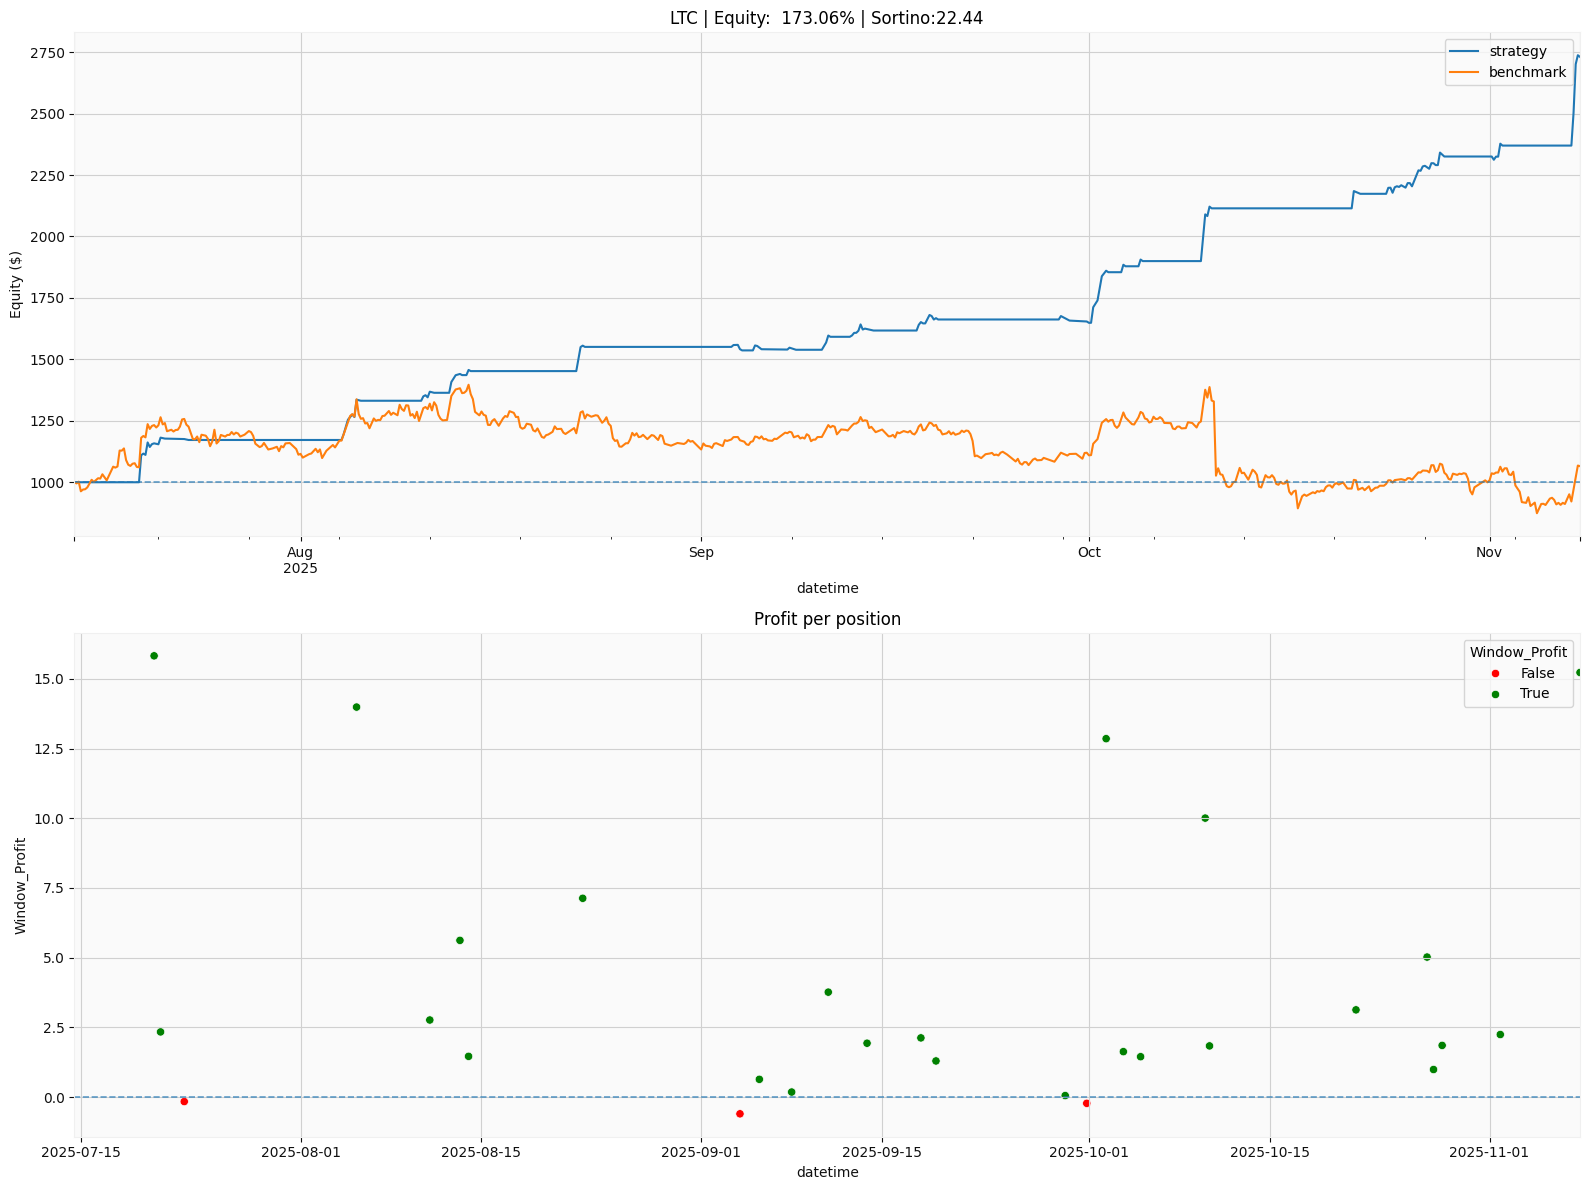

In [29]:
# plots
start = df.index[0]
end = df.index[-1]
win_profit = profit_df['Window_Profit'] * 100
fig, axes = plt.subplots(2, 1, figsize=(16, 12))
profit_df['Equity'].plot(ax=axes[0],
                         title=f'{symbols[0]} | Equity:  {stats["total_profit_pct"]:.2f}% | Sortino:{stats['sortino']:.2f}',
                         label='strategy')
df_bench_mark['equity'].plot(ax=axes[0], label='benchmark', secondary_y=False)
axes[0].set_ylabel('Equity ($)')
axes[0].set_xlim(start, end)
axes[0].legend()
# axes[0].set_yscale('log')
axes[0].axhline(start_equity, linestyle='--', linewidth=1.2, alpha=0.7)
sns.scatterplot(x=profit_df.index, y=win_profit, ax=axes[1], hue=win_profit > 0, palette={True: 'green', False: 'red'})
axes[1].set_title('Profit per position')
axes[1].axhline(0.0, linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].set_xlim(start, end)
plt.tight_layout()
plt.show()

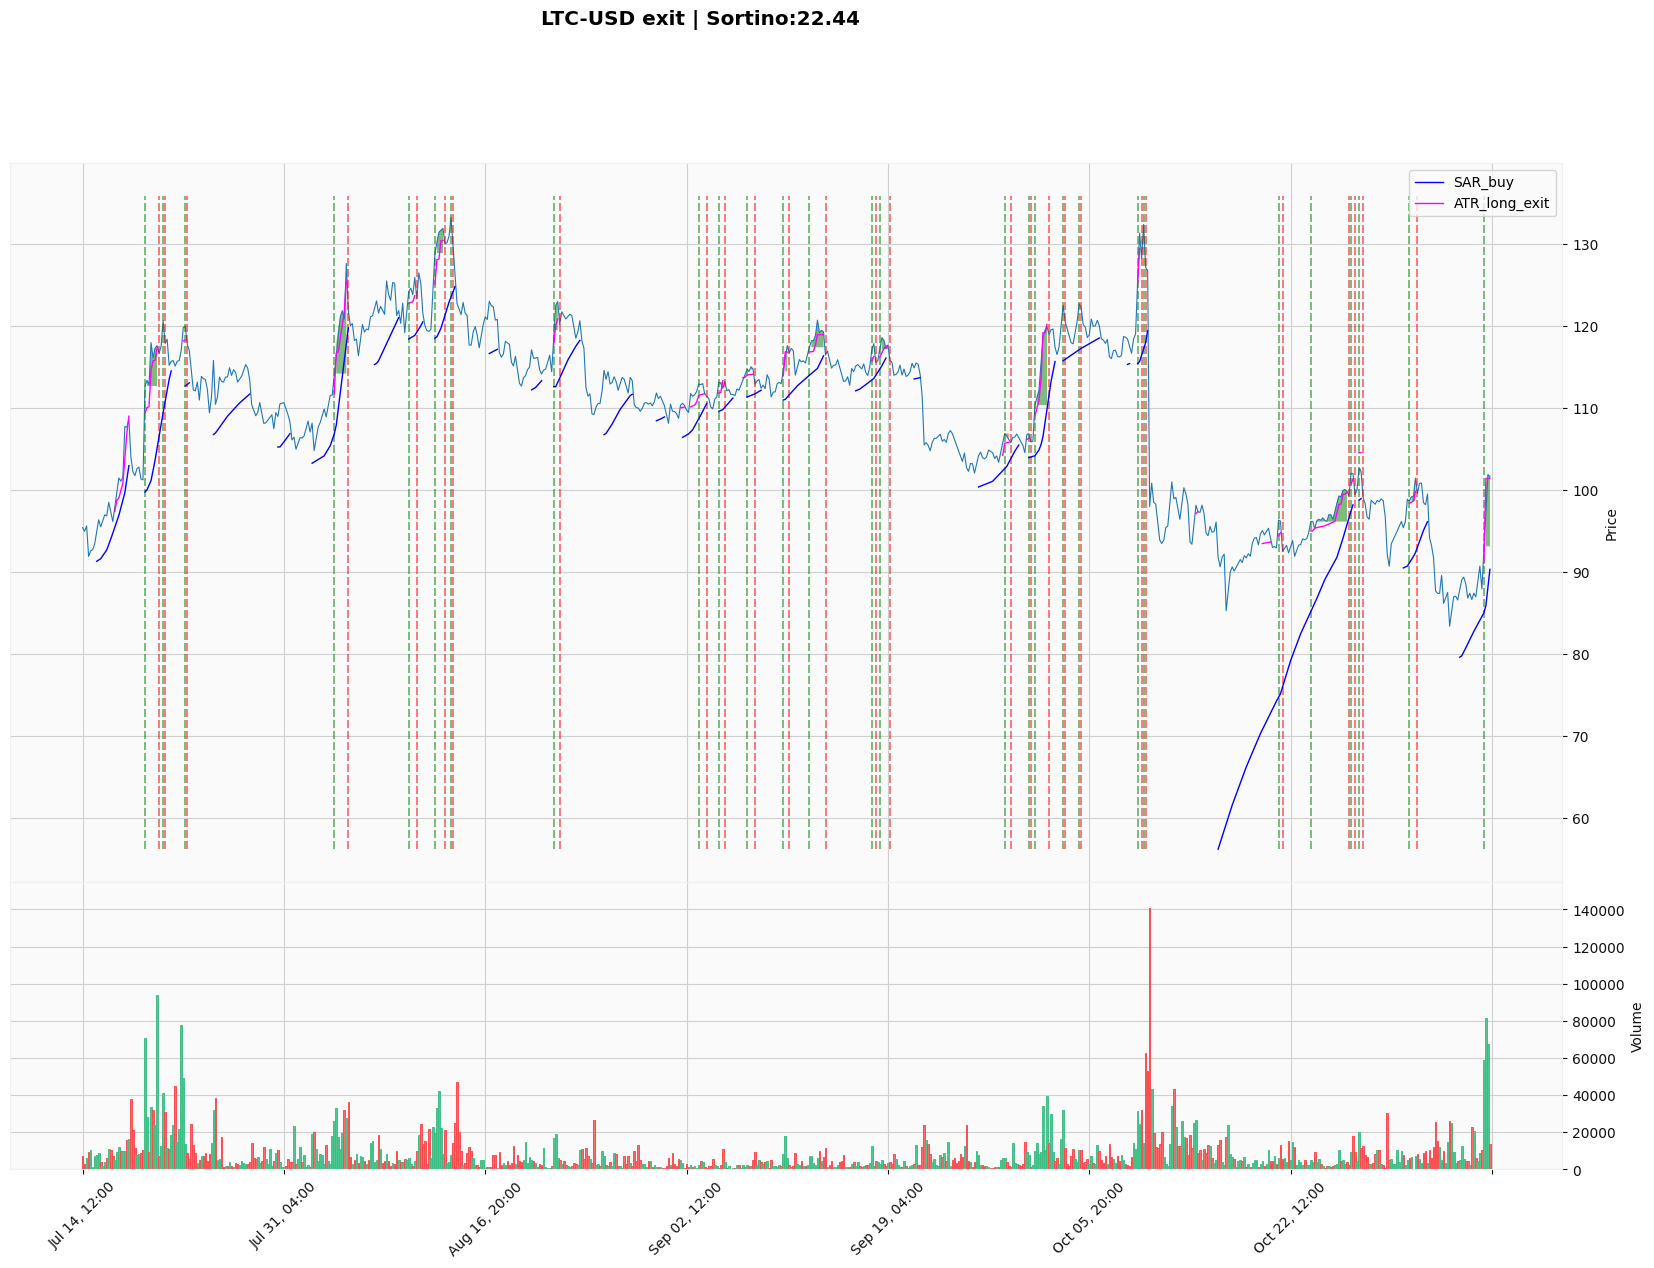

In [30]:
# Combine and color differently
##  Boolean where in position

y1_arr = signals['close'].values
filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']
in_position = signals['in_position']

y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]
# Build sorted timestamps with colors (keeps colors aligned with dates)
entries = [(ts, 'g') for ts in filtered_entry[filtered_entry].index]
exits = [(ts, 'r') for ts in filtered_exit[filtered_exit].index]
pairs = sorted(entries + exits, key=lambda x: x[0])

# Extract in order expected by mplfinance
vline_dates = [ts for ts, _ in pairs]
vline_colors = [c for _, c in pairs]

zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 12),
    figscale=2.5,
    tight_layout=False,
    title=f"{symbols[0]}-USD exit | Sortino:{stats['sortino']:.2f}",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)

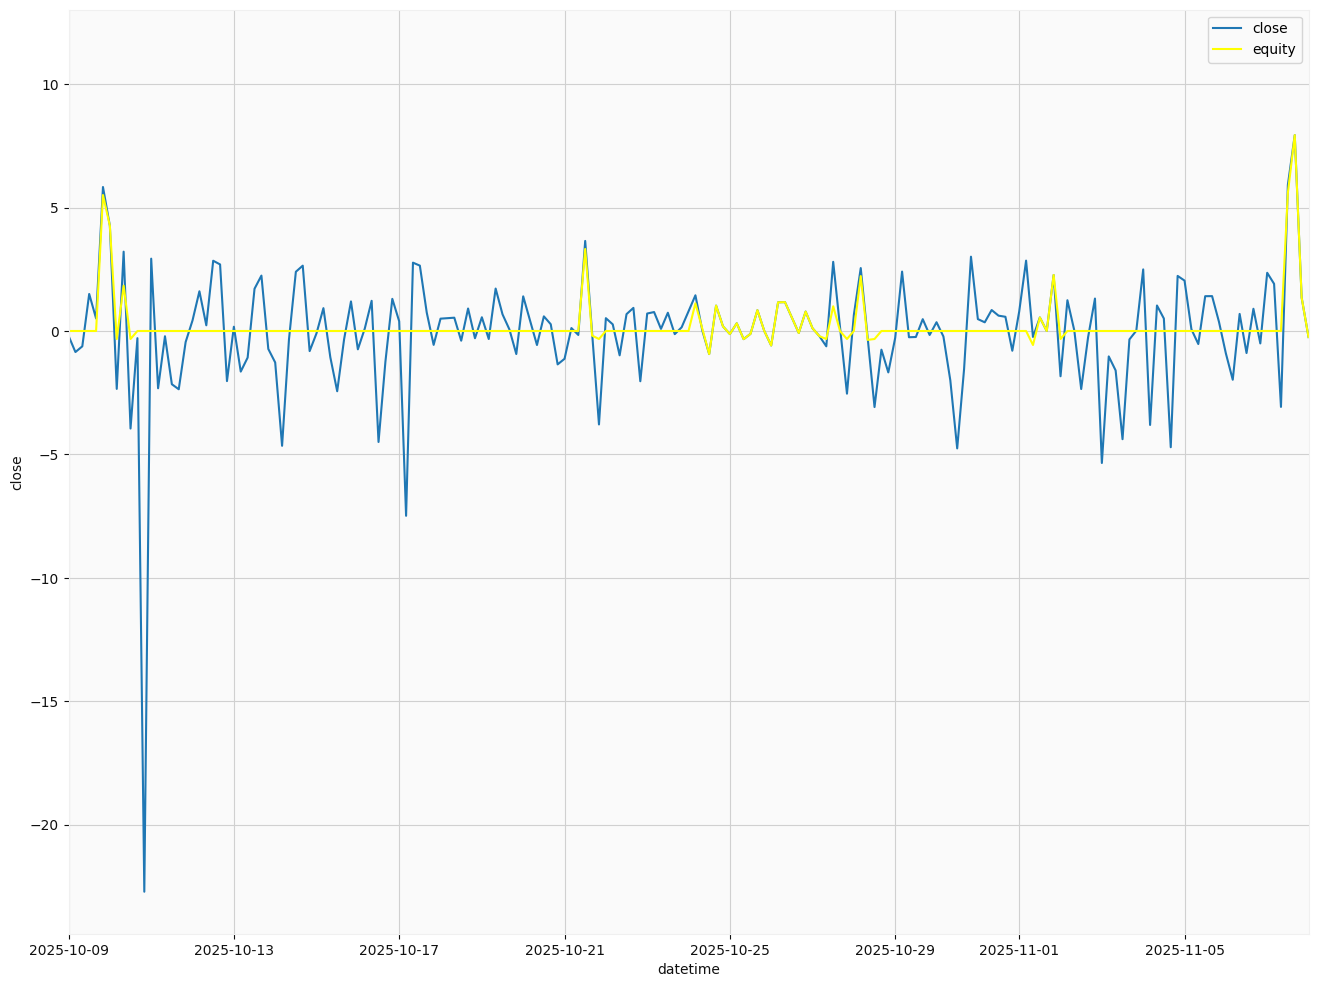

In [31]:
# compare pct change,  is the equity actually moving at the same rate as close??
equity_pct = profit_df['Equity'].pct_change() * 100
close_pct = df['close'].pct_change() * 100

fig = plt.figure(figsize=(16, 12))
sns.lineplot(close_pct, label='close')
sns.lineplot(equity_pct, color='yellow', label='equity')

ax = plt.gca()
ax.set_xlim(end - pd.Timedelta(days=30), end)
plt.legend()
plt.show()

